# Evaluating ENSO in a climate model

This notebook compares ENSO in a CMIP6 historical simulation with observations, using the
diagnostics and metrics of the [CLIVAR ENSO Metrics Package](https://github.com/CLIVAR-PRP/enso_metrics) implemented in **xENSO**.

We will cover:

- **Diagnostics** — amplitude, seasonality, skewness and duration of ENSO, and their model-observation metrics
- **Life cycle and pattern** — how ENSO grows and decays, and where along the equator it peaks
- **El Niño and La Niña** — event durations and the longitude of the peak of each event
- **Teleconnections** — the SST anomalies associated with ENSO outside the tropical Pacific
- **Collections** — all the metrics of a CLIVAR collection in one table

xENSO is not the official implementation of the CLIVAR metrics: use the original package for results that
must be comparable with published values. See the ENSO metrics page of the documentation for details.

## Data

The model is ACCESS-CM2 (member r1i1p1f1), whose sea surface temperature (`tos`) has been regridded to a
regular 1° grid. The observations are HadISST, on the same grid. The model-observation metrics require both
datasets on the same grid, and all fields must be ocean-only: `tos` is, while `ts` would need to be masked
over land first.

Both datasets are compared over their common period, 1950-2014, between 60°S and 60°N. Replace the paths
with your own files.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import xenso

plt.rcParams["font.family"] = "monospace"

print(f"xenso version: {xenso.__version__}")

xenso version: 0.1.dev161+g4cdff7986.d20260929


In [2]:
period = slice("1950-01-01", "2014-12-31")
latitudes = slice(-60, 60)

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)  # the model uses a noleap calendar
model = xr.open_dataset(
    "/glade/derecho/scratch/griverat/ESGF_regrid/ACCESS-CM2.r1i1p1f1.tos.nc", decode_times=time_coder
)
model = model["tos"].sel(time=period, lat=latitudes).load()

obs = xr.open_dataset("/glade/derecho/scratch/griverat/OBS/HadISST_sst.nc")["sst"]
obs = obs.rename(latitude="lat", longitude="lon").sortby("lat").sel(time=period, lat=latitudes).load()
obs = obs.where(obs > -5)  # missing values

# the same monthly time axis for both, for convenience in the plots
obs = obs.assign_coords(time=model.time)
model

<xarray.DataArray 'tos' (time: 780, lat: 120, lon: 360)> Size: 135MB
array([[[ 1.0932696 ,  1.0898098 ,  1.089605  , ...,  1.056129  ,
          1.0853283 ,  1.0940968 ],
        [ 1.091485  ,  1.0932205 ,  1.1107073 , ...,  1.1510159 ,
          1.081649  ,  1.0840236 ],
        [ 1.198564  ,  1.1514685 ,  1.1283069 , ...,  1.7704611 ,
          1.4607174 ,  1.2836026 ],
        ...,
        [ 8.269678  ,  8.189623  ,  7.778456  , ...,         nan,
                 nan,  8.290736  ],
        [ 8.282986  ,  8.303295  ,  8.090359  , ...,         nan,
          8.485     ,  8.27421   ],
        [ 8.197847  ,  8.46164   ,  8.338306  , ...,  9.364906  ,
          8.449435  ,  8.089919  ]],

       [[ 2.476519  ,  2.5587804 ,  2.6201415 , ...,  2.2411058 ,
          2.3061414 ,  2.3908987 ],
        [ 2.4794116 ,  2.5100079 ,  2.5705106 , ...,  2.5917833 ,
          2.500918  ,  2.4598954 ],
        [ 2.7793043 ,  2.7144666 ,  2.6703844 , ...,  3.2662706 ,
          3.0699751 ,  2.8826644 ],
...
        [11.946197  , 12.024205  , 11.7479515 , ...,         nan,
                 nan, 11.854485  ],
        [11.694006  , 11.884124  , 11.557809  , ...,         nan,
         11.373367  , 11.403503  ],
        [10.9933195 , 11.148709  , 11.14517   , ..., 11.557534  ,
         11.104121  , 10.862281  ]],

       [[-0.03651707, -0.13237005, -0.17460273, ...,  0.3750839 ,
          0.23638923,  0.08304723],
        [ 0.42747012,  0.2896174 ,  0.21982439, ...,  1.0687402 ,
          0.8462049 ,  0.60646814],
        [ 0.9979614 ,  0.8851403 ,  0.8187861 , ...,  1.6361551 ,
          1.3982704 ,  1.1658357 ],
        ...,
        [ 9.970552  , 10.060277  ,  9.714297  , ...,         nan,
                 nan,  9.862997  ],
        [ 9.954582  , 10.1329155 ,  9.965109  , ...,         nan,
          9.66902   ,  9.674002  ],
        [ 9.485745  ,  9.7224455 ,  9.840069  , ..., 10.3329935 ,
          9.549643  ,  9.377962  ]]], shape=(780, 120, 360), dtype=float32)
Coordinates:
  * time     (time) object 6kB 1950-01-15 00:00:00 ... 2014-12-15 00:00:00
  * lat      (lat) float64 960B -59.5 -58.5 -57.5 -56.5 ... 56.5 57.5 58.5 59.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      Sea Surface Temperature
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello
    history:        2019-11-08T18:45:39Z altered by CMOR: replaced missing va...

## ENSO diagnostics

Each diagnostic returns a Dataset with the diagnostic as `value` and, when CLIVAR defines one, an `error`.
As in CLIVAR, the fields are converted to anomalies over the whole period and linearly detrended.
`xenso.compare` turns a model and an observed diagnostic into a metric, by default the absolute relative
difference in %.

In [3]:
diagnostics = {
    "amplitude (°C)": xenso.enso_amplitude,
    "seasonality (NDJ/MAM)": xenso.enso_seasonality,
    "skewness": xenso.enso_skewness,
    "duration (months)": xenso.enso_duration,
}

rows = []
for name, diagnostic in diagnostics.items():
    model_result, obs_result = diagnostic(model), diagnostic(obs)
    metric, _ = xenso.compare(model_result, obs_result)
    rows.append(
        {
            "diagnostic": name,
            "CLIVAR": obs_result.attrs["clivar_name"],
            "ACCESS-CM2": float(model_result["value"]),
            "HadISST": float(obs_result["value"]),
            "metric (%)": float(metric),
        }
    )
pd.DataFrame(rows).set_index("diagnostic").round(2)

,CLIVAR,ACCESS-CM2,HadISST,metric (%)
diagnostic,,,,
amplitude (°C),EnsoAmpl,0.82,0.81,0.96
seasonality (NDJ/MAM),EnsoSeasonality,1.31,1.85,29.23
skewness,EnsoSstSkew,-0.10,0.26,138.97
duration (months),EnsoDuration,12.00,13.00,7.69


## ENSO life cycle

The life cycle is the regression of the monthly Niño 3.4 SST anomaly around each year onto its value in
December: it shows how anomalies grow before the ENSO peak (lag 0) and decay after it. The duration above
is the number of months during which it stays above 0.25. `enso_lifecycle_rmse` compares the two life cycles.

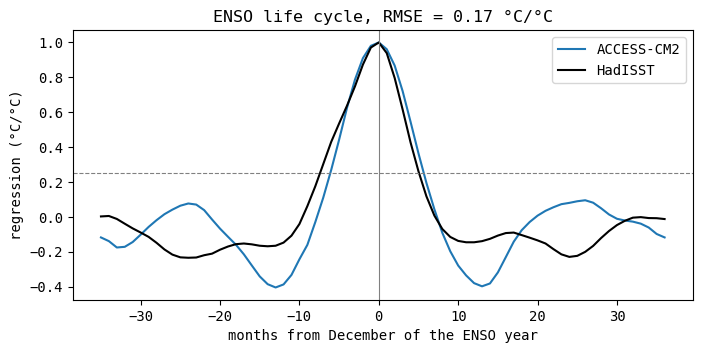

In [4]:
lifecycle = xenso.enso_lifecycle_rmse(model, obs)

fig, ax = plt.subplots(figsize=(8, 3.5))
lifecycle.model.plot(ax=ax, label="ACCESS-CM2")
lifecycle.obs.plot(ax=ax, label="HadISST", color="k")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set(xlabel="months from December of the ENSO year", ylabel="regression (°C/°C)")
ax.set_title(f"ENSO life cycle, RMSE = {float(lifecycle.value):.2f} °C/°C")
ax.legend();

## ENSO pattern along the equator

The December SST anomaly along the equator (5°S-5°N) is regressed onto the Niño 3.4 index. Many models
extend ENSO too far into the western Pacific; here the model and the observations agree closely.

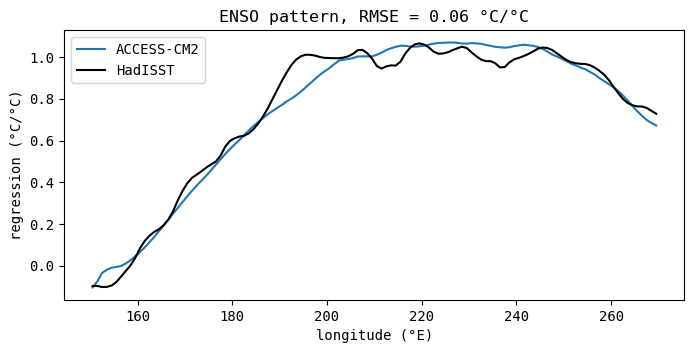

In [5]:
pattern = xenso.enso_pattern_rmse(model, obs)

fig, ax = plt.subplots(figsize=(8, 3.5))
pattern.model.plot(ax=ax, label="ACCESS-CM2")
pattern.obs.plot(ax=ax, label="HadISST", color="k")
ax.set(xlabel="longitude (°E)", ylabel="regression (°C/°C)")
ax.set_title(f"ENSO pattern, RMSE = {float(pattern.value):.2f} °C/°C")
ax.legend();

## El Niño and La Niña

Events are detected when the December Niño 3.4 anomaly exceeds 0.75 standard deviations. For each event,
`enso_event_duration` counts the months the anomaly stays beyond half a standard deviation, and
`enso_diversity` finds the longitude where the equatorial anomaly peaks. The diversity is the interquartile
range of those longitudes.

In [6]:
rows = []
for name, sst in [("ACCESS-CM2", model), ("HadISST", obs)]:
    diversity = xenso.enso_diversity(sst)
    rows.append(
        {
            "dataset": name,
            "El Niño duration (months)": float(xenso.enso_event_duration(sst, kind="nino").value),
            "La Niña duration (months)": float(xenso.enso_event_duration(sst, kind="nina").value),
            "diversity (°)": float(diversity.value),
            "eastern Pacific events (%)": float(diversity.eastern_fraction),
        }
    )
pd.DataFrame(rows).set_index("dataset").round(1)

,El Niño duration (months),La Niña duration (months),diversity (°),eastern Pacific events (%)
dataset,,,,
ACCESS-CM2,12.1,12.9,31.8,71.4
HadISST,12.2,20.6,38.5,31.2


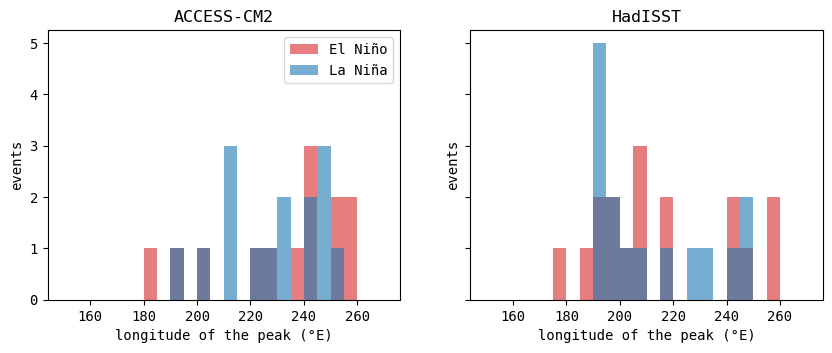

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, (name, sst) in zip(axes, [("ACCESS-CM2", model), ("HadISST", obs)], strict=True):
    peaks = xenso.enso_diversity(sst).peak_lon
    for kind, label, color in [("nino", "El Niño", "tab:red"), ("nina", "La Niña", "tab:blue")]:
        peaks.where(peaks.kind == kind, drop=True).plot.hist(
            ax=ax, bins=range(150, 275, 5), color=color, alpha=0.6, label=label
        )
    ax.set(title=name, xlabel="longitude of the peak (°E)", ylabel="events")
axes[0].legend();

## Teleconnections

The December-February SST anomaly between 60°S and 60°N is regressed onto the Niño 3.4 index of the same
season. The comparison leaves out the equatorial Pacific (15°S-15°N, 120°E-75°W), so it measures the
remote response. Besides the RMSE, the result gives the pattern correlation and the ratio of spatial
standard deviations, e.g. for a Taylor diagram.

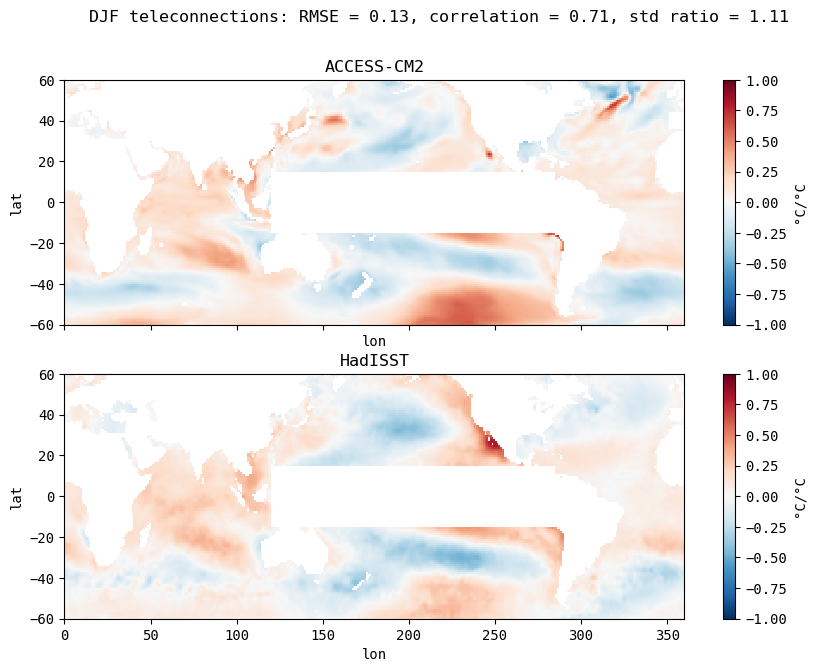

In [8]:
teleconnection = xenso.enso_teleconnection(model, obs, season="DJF")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, (name, field) in zip(
    axes, [("ACCESS-CM2", teleconnection.model), ("HadISST", teleconnection.obs)], strict=True
):
    field.plot(ax=ax, vmin=-1, vmax=1, cmap="RdBu_r", cbar_kwargs={"label": "°C/°C"})
    ax.set_title(name)
fig.suptitle(
    f"DJF teleconnections: RMSE = {float(teleconnection.value):.2f}, "
    f"correlation = {float(teleconnection.correlation):.2f}, "
    f"std ratio = {float(teleconnection.std_ratio):.2f}"
);

## A whole collection

`clivar_collection` computes the metrics of the CLIVAR ENSO_perf, ENSO_proc or ENSO_tel collection from
mappings of fields named `sst`, `pr`, `taux`, `ssh` and `thf`. Metrics whose variables are missing are
skipped, so with SST only we get the SST metrics of the performance collection. The `type` column tells
the kinds of metric apart: RMSEs compare whole profiles or maps, so they have no single model or observed
value, while the relative differences (in %) come with the model and observed diagnostics they compare.

In [9]:
performance = xenso.clivar_collection({"sst": model}, {"sst": obs}, "ENSO_perf")
performance.to_dataframe().round(3)

,type,value,model,obs
metric,,,,
BiasSstLonRmse,rmse,0.492,NaN,NaN
SeasonalSstLonRmse,rmse,0.227,NaN,NaN
EnsoSstLonRmse,rmse,0.057,NaN,NaN
EnsoSstTsRmse,rmse,0.169,NaN,NaN
EnsoAmpl,relative difference (%),0.962,0.817,0.810
EnsoSeasonality,relative difference (%),29.232,1.307,1.847
EnsoSstSkew,relative difference (%),138.966,-0.103,0.265
EnsoDuration,relative difference (%),7.692,12.000,13.000
EnsoSstDiversity,relative difference (%),17.532,31.750,38.500
